### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [56]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.normalization import BatchNormalization
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.optimizers import SGD
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

In [0]:
(train_X, train_Y), (test_X, test_Y) = keras.datasets.fashion_mnist.load_data()

In [0]:
trainX = train_X
trainY = train_Y
testX  = test_X
testY  = test_Y

In [60]:
print("trainX shape:", trainX.shape, "trainY shape:", trainY.shape)

trainX shape: (60000, 28, 28) trainY shape: (60000,)


In [61]:
#Original labels (0:10) from the train-dataset
print(trainY[0:10])

[9 0 0 3 0 2 7 2 5 5]


In [62]:
#Original labels (0:10) from the test-dataset
print(testY[0:10])

[9 2 1 1 6 1 4 6 5 7]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [0]:
#define a routine to show the dataset images and their labels in a given range
#of indices, at this point of writing, it doesn't support one-hot-label based plotting.
def show_mnist_fashion_img_n_lbl(img_data, labels, start_loc=0, end_loc=10):
  assert end_loc > start_loc
  # Define the text labels
  fashion_mnist_labels = ["T-shirt/top",  # index 0
                          "Trouser",      # index 1
                          "Pullover",     # index 2 
                          "Dress",        # index 3 
                          "Coat",         # index 4
                          "Sandal",       # index 5
                          "Shirt",        # index 6 
                          "Sneaker",      # index 7 
                          "Bag",          # index 8 
                          "Ankle boot"]   # index 9
  for x in range(start_loc, end_loc):
    print ("at {}-(th/st/nd/rd) position in label-set: {}, the label-{} is a/an: {} as below:".format(x, labels, str(labels[x]), fashion_mnist_labels[labels[x]]))
    plt.imshow(img_data[x])
    plt.show() 
    

at 0-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-9 is a/an: Ankle boot as below:


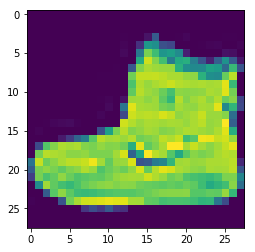

at 1-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-0 is a/an: T-shirt/top as below:


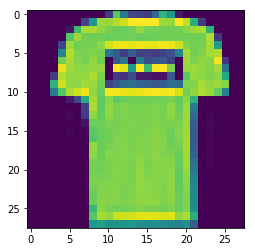

at 2-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-0 is a/an: T-shirt/top as below:


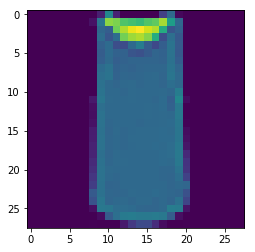

at 3-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-3 is a/an: Dress as below:


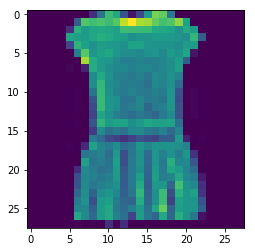

at 4-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-0 is a/an: T-shirt/top as below:


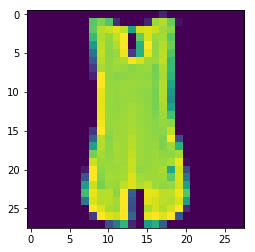

at 5-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-2 is a/an: Pullover as below:


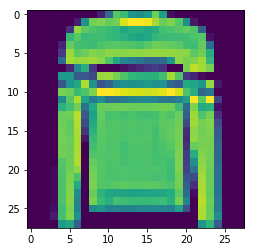

at 6-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-7 is a/an: Sneaker as below:


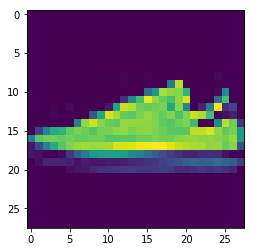

at 7-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-2 is a/an: Pullover as below:


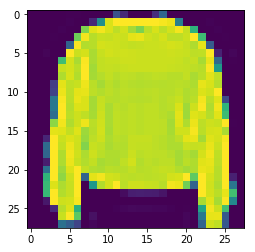

at 8-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-5 is a/an: Sandal as below:


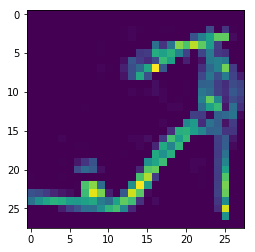

at 9-(th/st/nd) position in label-set: [9 0 0 ... 3 0 5], the label-5 is a/an: Sandal as below:


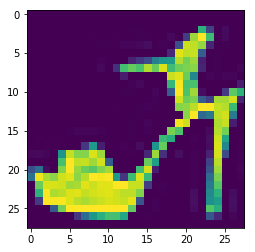

In [64]:
  show_mnist_fashion_img_n_lbl(trainX,trainY, 0, 10 )

In [65]:
L=pd.DataFrame(trainY)
L[0].value_counts()

9    6000
8    6000
7    6000
6    6000
5    6000
4    6000
3    6000
2    6000
1    6000
0    6000
Name: 0, dtype: int64

In [0]:
#Represent Training & Testing samples suitable for 
#tensorflow backend
trainX=trainX.reshape(trainX.shape[0],28,28,1).astype('float32')
testX=testX.reshape(testX.shape[0],28,28,1).astype('float32')

In [67]:
testX.shape

(10000, 28, 28, 1)

In [0]:
trainX/=255
testX/=255

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**


In [69]:
trainY=np_utils.to_categorical(trainY,10)
testY=np_utils.to_categorical(testY,10)
#Print the one-hot encoded counetrpart for the train-dataset labels
print(trainY[0:5])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [70]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


In [0]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [0]:
model.add(Flatten())

In [0]:
model.add(Dense(256,activation='relu'))

In [0]:
model.add(Dense(10,activation='softmax'))

In [0]:
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

### Execute the model using model.fit()

In [77]:
model.fit(trainX,trainY,batch_size=200,epochs=25,shuffle=True, verbose=2,validation_data=(testX,testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/25
 - 32s - loss: 0.6711 - acc: 0.7709 - val_loss: 0.6337 - val_acc: 0.7773
Epoch 2/25
 - 32s - loss: 0.5807 - acc: 0.7967 - val_loss: 0.5775 - val_acc: 0.7890
Epoch 3/25
 - 32s - loss: 0.5373 - acc: 0.8108 - val_loss: 0.5391 - val_acc: 0.8083
Epoch 4/25
 - 32s - loss: 0.5093 - acc: 0.8202 - val_loss: 0.5089 - val_acc: 0.8214
Epoch 5/25
 - 31s - loss: 0.4940 - acc: 0.8249 - val_loss: 0.4925 - val_acc: 0.8243
Epoch 6/25
 - 30s - loss: 0.4736 - acc: 0.8313 - val_loss: 0.5096 - val_acc: 0.8099
Epoch 7/25
 - 30s - loss: 0.4599 - acc: 0.8369 - val_loss: 0.4756 - val_acc: 0.8286
Epoch 8/25
 - 30s - loss: 0.4518 - acc: 0.8403 - val_loss: 0.4599 - val_acc: 0.8378
Epoch 9/25
 - 30s - loss: 0.4420 - acc: 0.8432 - val_loss: 0.4527 - val_acc: 0.8392
Epoch 10/25
 - 31s - loss: 0.4310 - acc: 0.8483 - val_loss: 0.4509 - val_acc: 0.8408
Epoch 11/25
 - 30s - loss: 0.4238 - acc: 0.8518 - val_loss: 0.4332 - val_acc: 0.8489
Epoch 12/25
 - 30s - los

In [79]:
# Take a look at the model summary
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_3 (Dense)              (None, 256)               1384704   
_________________________________________________________________
dense_4 (Dense)              (None, 10)                2570      
Total params: 1,387,594
Trainable params: 1,387,594
Non-trainable params: 0
_________________________________________________________________


In [80]:
score=model.evaluate(testX,testY)
score

10000/10000 [==============================] - 2s 180us/step


[0.3710721165657043, 0.8717]

In [0]:
y_predict = model.predict(testX)

In [82]:
y_predict[0]

array([2.2250826e-05, 5.9316153e-06, 2.1101607e-05, 8.3174127e-06,
       1.3801130e-05, 3.3688981e-02, 6.1246086e-05, 1.8377666e-01,
       5.1891264e-03, 7.7721262e-01], dtype=float32)

In [83]:
np.argmax(y_predict[0])

9

In [78]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(test_Y,y_pred)
print(cm)

[[767   1  43  43   2   1 131   0  12   0]
 [  2 965   2  23   3   0   3   0   2   0]
 [  8   2 917  10  29   1  28   1   4   0]
 [ 10   8  28 908  17   0  24   0   5   0]
 [  0   1 275  39 623   0  59   0   3   0]
 [  0   0   0   1   0 949   0  39   1  10]
 [ 97   1 177  33  50   0 629   0  13   0]
 [  0   0   0   0   0  27   0 943   0  30]
 [  3   1  15   6   3   2   1   6 963   0]
 [  0   0   0   0   0   9   0  43   1 947]]


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [90]:
model1=Sequential()
model1.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(256,activation='relu'))
#Normalize input data
model1.add(BatchNormalization(input_shape=(28,28,1)))
model1.add(Dense(256,activation='relu'))
model1.add(Dense(10,activation='softmax'))
model1.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])
model1.fit(trainX,trainY,batch_size=200,epochs=25,shuffle=True, verbose=2,validation_data=(testX,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


Train on 60000 samples, validate on 10000 samples
Epoch 1/25
 - 27s - loss: 0.6047 - acc: 0.8006 - val_loss: 0.4693 - val_acc: 0.8356
Epoch 2/25
 - 26s - loss: 0.4010 - acc: 0.8604 - val_loss: 0.4160 - val_acc: 0.8540
Epoch 3/25
 - 26s - loss: 0.3498 - acc: 0.8785 - val_loss: 0.3658 - val_acc: 0.8708
Epoch 4/25
 - 26s - loss: 0.3193 - acc: 0.8874 - val_loss: 0.3404 - val_acc: 0.8781
Epoch 5/25
 - 26s - loss: 0.2984 - acc: 0.8937 - val_loss: 0.3763 - val_acc: 0.8651
Epoch 6/25
 - 26s - loss: 0.2806 - acc: 0.9002 - val_loss: 0.3138 - val_acc: 0.8882
Epoch 7/25
 - 26s - loss: 0.2668 - acc: 0.9039 - val_loss: 0.3093 - val_acc: 0.8889
Epoch 8/25
 - 26s - loss: 0.2552 - acc: 0.9087 - val_loss: 0.2970 - val_acc: 0.8921
Epoch 9/25
 - 26s - loss: 0.2448 - acc: 0.9126 - val_loss: 0.3012 - val_acc: 0.8913
Epoch 10/25
 - 26s - loss: 0.2353 - acc: 0.9155 - val_loss: 0.3094 - val_acc: 0.8796
Epoch 11/25
 - 26s - loss: 0.2256 - acc: 0.9200 - val_loss: 0.2899 - val_acc: 0.8954
Epoch 12/25
 - 26s - los

In [91]:
# Take a look at the model summary
model1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_6 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_10 (Dense)             (None, 256)               1384704   
_________________________________________________________________
batch_normalization_2 (Batch (None, 256)               1024      
_________________________________________________________________
dense_11 (Dense)             (None, 256)               65792     
_________________________________________________________________
dense_12 (Dense)             (None, 10)                2570      
Total para

### Execute the model

In [92]:
score=model1.evaluate(testX,testY)
score

10000/10000 [==============================] - 1s 148us/step


[0.2629769501686096, 0.9063]

In [0]:
y_predict = model1.predict(testX)

In [94]:
y_predict[0]

array([9.0663627e-05, 1.5554929e-04, 3.2403399e-04, 2.6117440e-04,
       9.9606616e-05, 4.8099803e-03, 1.9506903e-04, 8.4510380e-03,
       1.0647250e-03, 9.8454815e-01], dtype=float32)

In [95]:
np.argmax(y_predict[0])

9

In [96]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(test_Y,y_pred)
print(cm)

[[800   0  24  20   4   1 142   0   9   0]
 [  0 976   3  17   2   0   1   0   1   0]
 [ 14   0 864  11  47   0  62   0   2   0]
 [  8   5  11 918  16   0  38   0   4   0]
 [  1   1  65  27 838   0  68   0   0   0]
 [  1   0   0   0   0 970   0  21   1   7]
 [ 64   0  55  24  41   0 806   0  10   0]
 [  0   0   0   0   0  10   0 985   0   5]
 [  3   0   2   4   2   3   4   5 977   0]
 [  0   0   0   0   0   8   1  62   0 929]]


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
opt = SGD(lr=0.001)

In [99]:
model2=Sequential()
model2.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Flatten())
model2.add(Dense(256,activation='relu'))
#Normalize input data
model2.add(BatchNormalization(input_shape=(28,28,1)))
model2.add(Dense(256,activation='relu'))
model2.add(Dense(10,activation='softmax'))
model2.compile(loss='categorical_crossentropy',optimizer=opt,metrics=['accuracy'])
model2.fit(trainX,trainY,batch_size=200,epochs=25,shuffle=True, verbose=2,validation_data=(testX,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


Train on 60000 samples, validate on 10000 samples
Epoch 1/25
 - 32s - loss: 1.0724 - acc: 0.6805 - val_loss: 0.7770 - val_acc: 0.7602
Epoch 2/25
 - 31s - loss: 0.7021 - acc: 0.7838 - val_loss: 0.6583 - val_acc: 0.7865
Epoch 3/25
 - 31s - loss: 0.6134 - acc: 0.8015 - val_loss: 0.6023 - val_acc: 0.7987
Epoch 4/25
 - 31s - loss: 0.5628 - acc: 0.8148 - val_loss: 0.5648 - val_acc: 0.8093
Epoch 5/25
 - 31s - loss: 0.5271 - acc: 0.8240 - val_loss: 0.5434 - val_acc: 0.8125
Epoch 6/25
 - 31s - loss: 0.5011 - acc: 0.8311 - val_loss: 0.5154 - val_acc: 0.8232
Epoch 7/25
 - 31s - loss: 0.4801 - acc: 0.8371 - val_loss: 0.4950 - val_acc: 0.8319
Epoch 8/25
 - 31s - loss: 0.4627 - acc: 0.8426 - val_loss: 0.4794 - val_acc: 0.8362
Epoch 9/25
 - 31s - loss: 0.4480 - acc: 0.8479 - val_loss: 0.4662 - val_acc: 0.8403
Epoch 10/25
 - 32s - loss: 0.4352 - acc: 0.8512 - val_loss: 0.4566 - val_acc: 0.8420
Epoch 11/25
 - 31s - loss: 0.4242 - acc: 0.8544 - val_loss: 0.4473 - val_acc: 0.8442
Epoch 12/25
 - 31s - los

In [100]:
# Take a look at the model summary
model2.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_7 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_7 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_13 (Dense)             (None, 256)               1384704   
_________________________________________________________________
batch_normalization_3 (Batch (None, 256)               1024      
_________________________________________________________________
dense_14 (Dense)             (None, 256)               65792     
_________________________________________________________________
dense_15 (Dense)             (None, 10)                2570      
Total para

In [101]:
score=model2.evaluate(testX,testY)
score

10000/10000 [==============================] - 2s 155us/step


[0.3707969584465027, 0.8674]

In [0]:
y_predict = model2.predict(testX)

In [103]:
y_predict[0]

array([8.1494922e-04, 1.5334400e-03, 6.1795302e-04, 1.6747630e-03,
       1.3679183e-03, 5.5366814e-02, 2.2643006e-03, 2.3996356e-01,
       7.6680738e-03, 6.8872821e-01], dtype=float32)

In [106]:
np.argmax(y_predict[0])

9

In [105]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(test_Y,y_pred)
print(cm)

[[829   0  16  40   6   2  95   0  12   0]
 [  3 958   3  26   5   0   4   0   1   0]
 [ 14   1 780  15 125   1  57   0   7   0]
 [ 19   7   9 889  41   0  31   0   4   0]
 [  2   0  76  31 835   1  49   0   6   0]
 [  0   0   0   2   0 943   0  35   2  18]
 [153   0  94  32 111   0 586   0  24   0]
 [  0   0   0   0   0  26   0 932   1  41]
 [  2   1   4   5   4   4   7   4 968   1]
 [  0   0   0   0   0  10   1  35   0 954]]


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
opt = SGD(lr=0.03)

In [108]:
model3=Sequential()
model3.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Flatten())
model3.add(Dense(100,activation='sigmoid'))
#Normalize input data
model3.add(BatchNormalization(input_shape=(28,28,1)))
model3.add(Dense(100,activation='sigmoid'))
model3.add(Dense(10,activation='softmax'))
model3.compile(loss='categorical_crossentropy',optimizer=opt,metrics=['accuracy'])
model3.fit(trainX,trainY,batch_size=200,epochs=25,shuffle=True, verbose=2,validation_data=(testX,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


Train on 60000 samples, validate on 10000 samples
Epoch 1/25
 - 20s - loss: 0.9475 - acc: 0.7415 - val_loss: 0.6678 - val_acc: 0.7884
Epoch 2/25
 - 20s - loss: 0.5743 - acc: 0.8213 - val_loss: 0.5459 - val_acc: 0.8229
Epoch 3/25
 - 20s - loss: 0.4813 - acc: 0.8434 - val_loss: 0.4745 - val_acc: 0.8414
Epoch 4/25
 - 20s - loss: 0.4289 - acc: 0.8567 - val_loss: 0.4360 - val_acc: 0.8532
Epoch 5/25
 - 19s - loss: 0.3931 - acc: 0.8684 - val_loss: 0.4280 - val_acc: 0.8491
Epoch 6/25
 - 19s - loss: 0.3652 - acc: 0.8771 - val_loss: 0.3839 - val_acc: 0.8687
Epoch 7/25
 - 20s - loss: 0.3446 - acc: 0.8825 - val_loss: 0.3600 - val_acc: 0.8785
Epoch 8/25
 - 20s - loss: 0.3264 - acc: 0.8900 - val_loss: 0.3613 - val_acc: 0.8726
Epoch 9/25
 - 19s - loss: 0.3123 - acc: 0.8940 - val_loss: 0.3646 - val_acc: 0.8703
Epoch 10/25
 - 19s - loss: 0.3008 - acc: 0.8973 - val_loss: 0.3244 - val_acc: 0.8848
Epoch 11/25
 - 19s - loss: 0.2898 - acc: 0.8998 - val_loss: 0.3214 - val_acc: 0.8843
Epoch 12/25
 - 20s - los

## Review model

In [109]:
# Take a look at the model summary
model3.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_8 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_16 (Dense)             (None, 100)               540900    
_________________________________________________________________
batch_normalization_4 (Batch (None, 100)               400       
_________________________________________________________________
dense_17 (Dense)             (None, 100)               10100     
_________________________________________________________________
dense_18 (Dense)             (None, 10)                1010      
Total para

### Run the model

In [114]:
score=model3.evaluate(testX,testY)
score

10000/10000 [==============================] - 1s 134us/step


[0.2757927752971649, 0.9007]

In [0]:
y_predict = model3.predict(testX)

In [116]:
y_predict[0]

array([1.0195177e-04, 1.1078999e-04, 5.6111539e-04, 9.1142487e-05,
       5.6580006e-04, 2.8631995e-03, 3.3475246e-04, 6.3682408e-03,
       8.2038454e-04, 9.8818260e-01], dtype=float32)

In [117]:
np.argmax(y_predict[0])

9

In [118]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(test_Y,y_pred)
print(cm)

[[901   0  21  20   4   1  47   0   6   0]
 [  1 979   1  14   2   0   2   0   1   0]
 [ 16   1 911   8  34   0  30   0   0   0]
 [ 16   7  16 909  24   0  27   0   1   0]
 [  2   0 129  24 812   0  33   0   0   0]
 [  0   0   1   1   0 959   0  24   1  14]
 [156   2 103  33  62   0 635   0   9   0]
 [  0   0   0   0   0   7   0 960   0  33]
 [  5   2   3   5   5   0   4   5 971   0]
 [  0   0   0   0   0   4   1  25   0 970]]
